# Modelo LightGBM

Clasificación binaria de diabetes. El dataset está desbalanceado con un 8.5% de positivos.

Optimizamos PR-AUC. Reportamos también ROC-AUC y Recall.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, recall_score, precision_score, f1_score, fbeta_score
)

# semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)

## Carga y capa compartida

Esta parte es común para todos los modelos. Aplicamos los mismos filtros y el mismo split que el resto del equipo para que el test sea idéntico y los modelos comparables.

Quitamos las filas con bmi de 65 o más y las de género Other. Reagrupamos smoking_history en 4 grupos uniendo ever, former y not current bajo former.

In [2]:
data_path = "../data/diabetes_prediction_dataset.csv"

data = pd.read_csv(data_path)
print("Filas en bruto", data.shape[0])

# filtros
data = data[data["bmi"] < 65]
data = data[data["gender"] != "Other"]

# reagrupado de smoking_history en 4 grupos
smoking_map = {
    "No Info": "No Info",
    "never": "never",
    "current": "current",
    "former": "former",
    "ever": "former",
    "not current": "former",
}
data["smoking_history"] = data["smoking_history"].map(smoking_map)

print("Filas tras filtrar", data.shape[0])
print("Grupos de smoking_history", sorted(data["smoking_history"].unique()))
data.head()

Filas en bruto 100000
Filas tras filtrar 99935
Grupos de smoking_history ['No Info', 'current', 'former', 'never']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Split y tipado

Separamos en train y test de forma estratificada por la variable objetivo, con semilla fija para que el reparto sea reproducible y los modelos comparables sobre el mismo test.

LightGBM no necesita escalar las numéricas ni codificar las categóricas. Marcamos las categóricas como tipo category y las trata de forma nativa.

In [5]:
# objetivo y predictores
X = data.drop(columns=["diabetes"])
y = data["diabetes"]

# split estratificado con semilla fija, test reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()

# categóricas nativas para LightGBM
cat_cols = ["gender", "smoking_history"]
for c in cat_cols:
    X_train[c] = X_train[c].astype("category")
    X_test[c] = X_test[c].astype("category").cat.set_categories(X_train[c].cat.categories)

print(f"Train {X_train.shape}  diabéticos {y_train.mean()*100:.2f}%")
print(f"Test  {X_test.shape}  diabéticos {y_test.mean()*100:.2f}%")

Train (79948, 8)  diabéticos 8.49%
Test  (19987, 8)  diabéticos 8.49%


## Modelo base

Entrenamos un LightGBM por defecto, sin optimizar, como punto de partida para medir cuánto mejora el modelo ajustado. Elegimos el umbral maximizando F2 en train, que da más peso al recall porque en un cribado pesa más no dejar sin detectar a un diabético que tener alguna falsa alarma.

In [5]:
base_model = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)
base_model.fit(X_train, y_train)

proba_tr = base_model.predict_proba(X_train)[:, 1]
proba_te = base_model.predict_proba(X_test)[:, 1]

ths = np.linspace(0.01, 0.99, 99)
opt_t = ths[np.argmax([fbeta_score(y_train, (proba_tr >= t).astype(int), beta=2) for t in ths])]

print(f"PR-AUC  {average_precision_score(y_test, proba_te):.4f}")
print(f"ROC-AUC {roc_auc_score(y_test, proba_te):.4f}")
print(f"Recall  {recall_score(y_test, (proba_te >= opt_t).astype(int)):.4f}  umbral {opt_t:.3f}")

PR-AUC  0.8845
ROC-AUC 0.9795
Recall  0.8362  umbral 0.170


## Optimización de hiperparámetros

Buscamos los hiperparámetros con Optuna, más eficiente que un grid porque aprende de los intentos previos y se concentra en las zonas prometedoras, pero arrancando con una tanda de intentos aleatorios para explorar bien el espacio antes de afinar. Evaluamos cada combinación con validación cruzada estratificada de 5 particiones sobre el train, optimizando el PR-AUC.

Los rangos de búsqueda son los habituales para LightGBM, amplios para que el óptimo quede dentro pero sin valores absurdos que solo gastarían tiempo. Cubren la complejidad del árbol, la regularización y el submuestreo de filas y columnas.

Dentro de cada partición usamos early stopping sobre el fold de validación así que el número de árboles lo decide el propio entrenamiento. Activamos también la poda, que descarta pronto las combinaciones que van claramente mal para dedicar más tiempo a las buenas. El test queda intacto y solo se usa al final.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# cv estratificada de 5 particiones sobre el train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def objective(trial):
    params = {
        "objective": "binary",
        "n_estimators": 5000,            # tope muy alto, el early stopping decide cuantos arboles usar
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 511),
        "max_depth": trial.suggest_int("max_depth", 3, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 300),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5),
        "max_bin": trial.suggest_int("max_bin", 63, 511),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 12.0),
        "random_state": SEED,
        "n_jobs": -1,
        "verbose": -1,
    }

    scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],            # early stopping sobre el fold de validacion
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(200, verbose=False)],
        )
        p = model.predict_proba(X_va)[:, 1]
        scores.append(average_precision_score(y_va, p))

        # poda, corta el trial si la media parcial va peor que la mediana de los demas
        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

# TPE multivariante con 30 intentos aleatorios iniciales para explorar el espacio
sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True, n_startup_trials=30)
pruner = optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=2)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=250, show_progress_bar=True)

completados = len([t for t in study.trials if t.state.name == "COMPLETE"])
print(f"\nMejor PR-AUC en CV  {study.best_value:.4f}")
print(f"Trials completados  {completados} de {len(study.trials)}")
print("Mejores parametros")
for k, v in study.best_params.items():
    print(" ", k, v)

Best trial: 71. Best value: 0.88858: 100%|██████████| 250/250 [3:07:02<00:00, 44.89s/it]   


Mejor PR-AUC en CV  0.8886
Trials completados  242 de 250
Mejores parametros
  learning_rate 0.02398962516763151
  num_leaves 434
  max_depth 3
  min_child_samples 106
  min_child_weight 0.023283263221368013
  subsample 0.5621330155294268
  colsample_bytree 0.6487175123807298
  reg_alpha 0.0004738997559119838
  reg_lambda 8.59673086276963e-06
  min_split_gain 0.19873624023851524
  max_bin 433
  scale_pos_weight 6.667904082223752


## Modelo final

Entrenamos el modelo definitivo con los mejores hiperparámetros encontrados. Para fijar el número de árboles repetimos la validación cruzada con esos parámetros y nos quedamos con la media de árboles que eligió el early stopping en cada partición. Después reentrenamos sobre todo el train y evaluamos en train y test para comprobar que no hay sobreajuste.

In [9]:
best_params = study.best_params.copy()
best_params.update({
    "objective": "binary", "subsample_freq": 1,
    "random_state": SEED, "n_jobs": -1, "verbose": -1,
})

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

iters = []
for tr_idx, va_idx in cv.split(X_train, y_train):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    m = lgb.LGBMClassifier(n_estimators=5000, **best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(200, verbose=False)])
    iters.append(m.best_iteration_)
n_trees = int(np.mean(iters))
print("Arboles por particion", iters, "-> usamos", n_trees)

final_model = lgb.LGBMClassifier(n_estimators=n_trees, **best_params)
final_model.fit(X_train, y_train)

proba_tr = final_model.predict_proba(X_train)[:, 1]
proba_te = final_model.predict_proba(X_test)[:, 1]

ths = np.linspace(0.01, 0.99, 99)
opt_t = ths[np.argmax([fbeta_score(y_train, (proba_tr >= t).astype(int), beta=2) for t in ths])]
print(f"\nUmbral F2 {opt_t:.3f}\n")

for nombre, y_true, proba in [("Train", y_train, proba_tr), ("Test", y_test, proba_te)]:
    pred = (proba >= opt_t).astype(int)
    print(nombre)
    print(f"  PR-AUC  {average_precision_score(y_true, proba):.4f}")
    print(f"  ROC-AUC {roc_auc_score(y_true, proba):.4f}")
    print(f"  Recall  {recall_score(y_true, pred):.4f}")

Arboles por particion [772, 639, 1010, 720, 1009] -> usamos 830

Umbral F2 0.530

Train
  PR-AUC  0.8940
  ROC-AUC 0.9814
  Recall  0.8695
Test
  PR-AUC  0.8891
  ROC-AUC 0.9807
  Recall  0.8574


El modelo final usa 830 árboles, que es la media de los que eligió el early stopping en cada partición. La búsqueda eligió árboles de profundidad 3, muy poco profundos, así que el problema se resuelve bien con árboles simples y bastante regularizados, sin necesidad de complicar el modelo.

El PR-AUC sale 0.8940 en train y 0.8891 en test, casi iguales, así que no hay sobreajuste. Además el test coincide con el 0.8886 de la validación cruzada, y eso confirma que el resultado es fiable. La mejora respecto al baseline, que daba 0.8845, es pequeña, pero es normal porque HbA1c y glucosa ya dejan el problema casi resuelto. El ROC-AUC se queda en 0.98. El recall en test es 0.857 en el umbral que elegimos con F2, es decir, con ese punto de corte el modelo detecta alrededor del 86% de los diabéticos. 

## Gráficas

Pintamos train y test juntas en la curva PR y la ROC para comprobar que van casi pegadas, señal de que no hay sobreajuste.

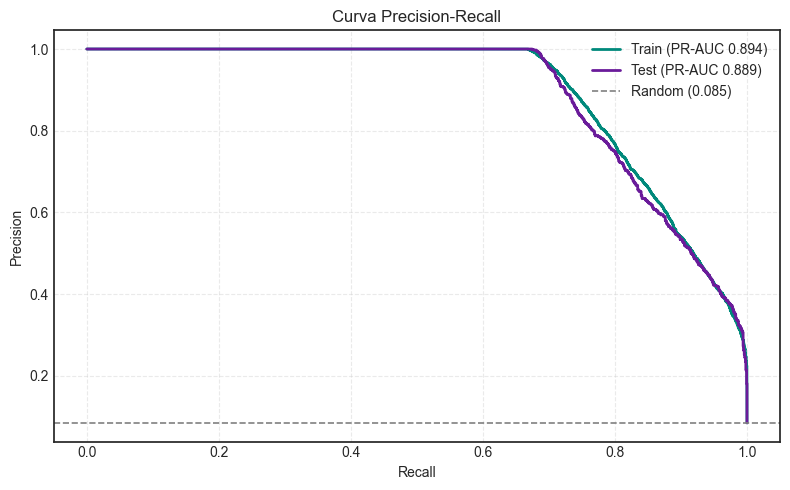

In [20]:
plt.style.use("seaborn-v0_8-white")

prevalencia = y_test.mean()

plt.figure(figsize=(8, 5))
for nombre, y_true, proba, color in [
    ("Train", y_train, proba_tr, "#00897B"),
    ("Test",  y_test,  proba_te, "#6A1B9A"),
]:
    prec, rec, _ = precision_recall_curve(y_true, proba)
    ap = average_precision_score(y_true, proba)
    plt.plot(rec, prec, color=color, lw=2, label=f"{nombre} (PR-AUC {ap:.3f})")
plt.axhline(prevalencia, ls="--", color="grey", lw=1.2, label=f"Random ({prevalencia:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

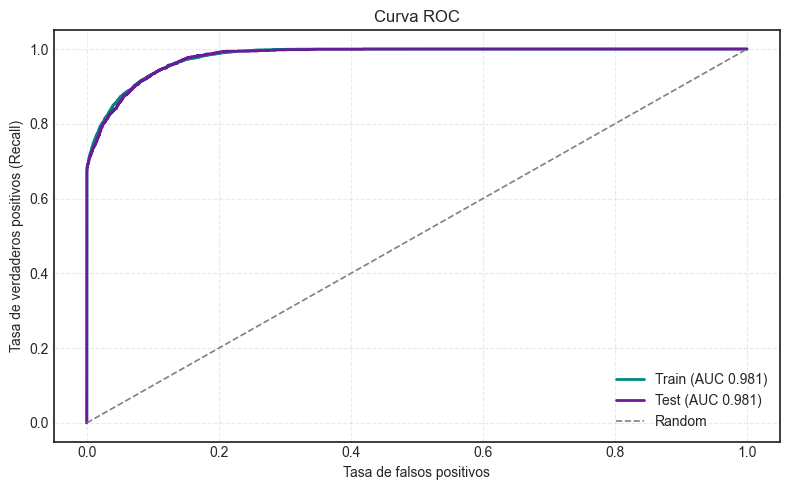

In [22]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 5))
for nombre, y_true, proba, color in [
    ("Train", y_train, proba_tr, "#00897B"),
    ("Test",  y_test,  proba_te, "#6A1B9A"),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{nombre} (AUC {auc:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="grey", lw=1.2, label="Random")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

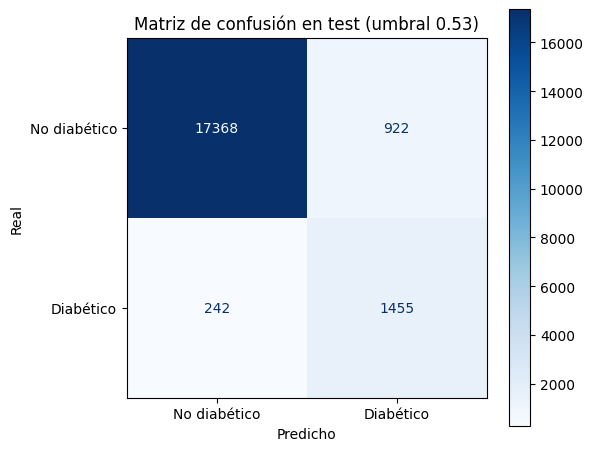

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

pred_te = (proba_te >= opt_t).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_te,
    display_labels=["No diabético", "Diabético"],
    cmap="Blues", colorbar=True, values_format="d", ax=ax,
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión en test (umbral {opt_t:.2f})")
plt.tight_layout()
plt.show()

De los 1697 diabéticos reales del test, el modelo detecta 1455 y se le escapan 242. A cambio marca como diabéticas a 922 personas sanas, que son las falsas alarmas. Es justo el equilibrio que buscábamos al elegir el umbral con F2, dar prioridad a detectar diabéticos aunque sea a costa de alguna falsa alarma.

## Elección del umbral

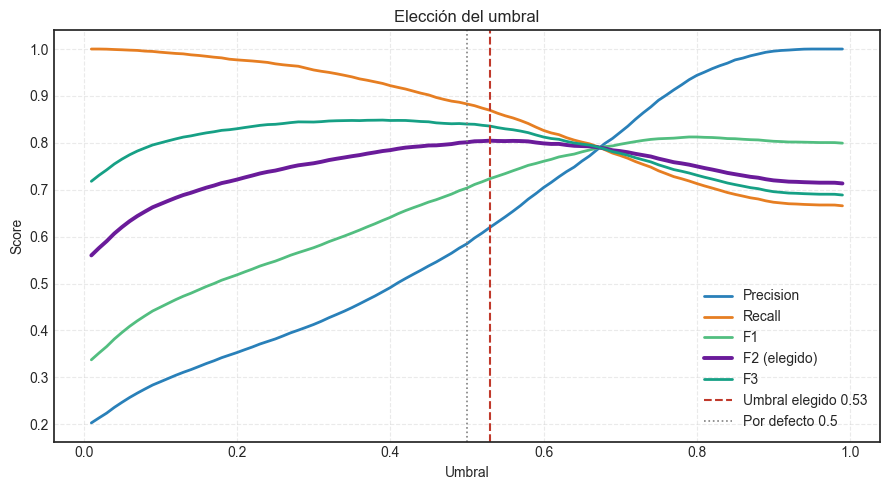

In [ ]:
from sklearn.metrics import precision_score

plt.style.use("seaborn-v0_8-white")
2
ths = np.linspace(0.01, 0.99, 99)
prec_l = [precision_score(y_train, (proba_tr >= t).astype(int), zero_division=0) for t in ths]
rec_l  = [recall_score(y_train, (proba_tr >= t).astype(int)) for t in ths]
f1_l   = [f1_score(y_train, (proba_tr >= t).astype(int)) for t in ths]
f2_l   = [fbeta_score(y_train, (proba_tr >= t).astype(int), beta=2) for t in ths]
f3_l   = [fbeta_score(y_train, (proba_tr >= t).astype(int), beta=3) for t in ths]

plt.figure(figsize=(9, 5))
plt.plot(ths, prec_l, color="#2980B9", lw=2, label="Precision")
plt.plot(ths, rec_l,  color="#E67E22", lw=2, label="Recall")
plt.plot(ths, f1_l,   color="#52BE80", lw=2, label="F1")
plt.plot(ths, f2_l,   color="#6A1B9A", lw=2.8, label="F2 (elegido)")
plt.plot(ths, f3_l,   color="#16A085", lw=2, label="F3")
plt.axvline(opt_t, ls="--", color="#C0392B", lw=1.5, label=f"Umbral elegido {opt_t:.2f}")
plt.axvline(0.5, ls=":", color="grey", lw=1.2, label="Por defecto 0.5")
plt.xlabel("Umbral")
plt.ylabel("Score")
plt.title("Elección del umbral")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

La gráfica muestra que al dar más peso al recall, de F1 a F2 a F3, el umbral óptimo baja. Nosotros hemos elegido F2 como equilibrio razonable entre recall y precisión, dándole más peso al recall, pero el umbral ideal depende de cuánto cueste no detectar a un diabético frente a dar una falsa alarma, algo que debería decidir un experto clínico. Si se quisiera priorizar aún más el recall, se podría usar F3 o fijar un recall objetivo.

## Interpretabilidad con SHAP

Usamos SHAP para ver qué variables pesan más en las predicciones del modelo y en qué dirección empujan.

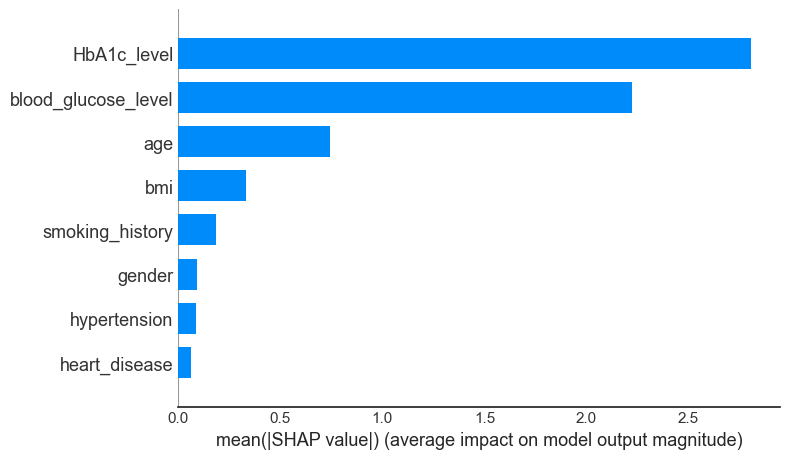

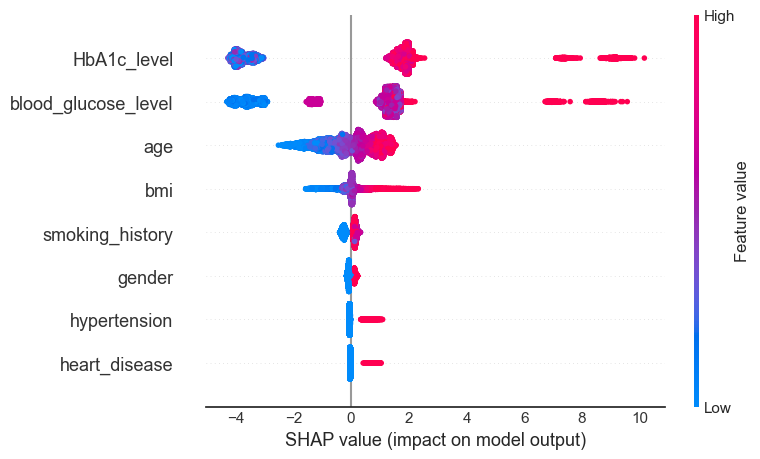

In [ ]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

X_plot = X_test.copy()
for c in cat_cols:
    X_plot[c] = X_plot[c].cat.codes

# ranking de importancia primero
shap.summary_plot(shap_values, X_plot, plot_type="bar", show=True)
# grafico de puntos
shap.summary_plot(shap_values, X_plot, show=True)

El gráfico de barras deja claro que dos variables dominan con diferencia, HbA1c y glucosa. Tiene todo el sentido clínico, porque son dos de los criterios más importantes con los que se diagnostica la diabetes. La edad y el IMC aportan algo secundario, y el tabaquismo, el género, la hipertensión y la enfermedad cardíaca apenas mueven la predicción.

El gráfico de puntos confirma la dirección y es coherente en todos los casos, valores altos de HbA1c, glucosa, edad e IMC empujan hacia diabetes y los valores bajos en contra. En HbA1c y glucosa se ve además que son casi decisivas, porque los puntos se separan en dos grupos con un hueco en el medio y algunos casos extremos disparan la predicción con mucha fuerza. La edad y el IMC tienen un efecto más gradual y repartido, y la hipertensión y la enfermedad cardíaca, al ser binarias, solo empujan un poco hacia diabetes cuando están presentes y no hacen nada cuando no lo están.

En conjunto el modelo se apoya sobre todo en los marcadores analíticos y aprende relaciones clínicamente lógicas, lo que confirma que no se basa en atajos extraños sino en señales con sentido médico.

## Modelo sin HbA1c ni glucosa

Como hemos visto, el modelo se apoya casi todo en HbA1c y glucosa, que son justo dos de los criterios con los que se diagnostica la diabetes. Por eso queremos ver qué pasa si las quitamos. Repetimos exactamente el mismo entrenamiento y la misma optimización, solo que sin esas dos variables, para ver cuánto se pierde.

In [11]:
# escenario de cribado sin analitica, quitamos las dos variables casi diagnosticas
sin_cols = ["HbA1c_level", "blood_glucose_level"]
X_train_sin = X_train.drop(columns=sin_cols)
X_test_sin  = X_test.drop(columns=sin_cols)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def objective_sin(trial):
    params = {
        "objective": "binary",
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 511),
        "max_depth": trial.suggest_int("max_depth", 3, 16),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 300),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5),
        "max_bin": trial.suggest_int("max_bin", 63, 511),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 12.0),
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_sin, y_train), start=1):
        X_tr, X_va = X_train_sin.iloc[tr_idx], X_train_sin.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
                  callbacks=[lgb.early_stopping(200, verbose=False)])
        scores.append(average_precision_score(y_va, model.predict_proba(X_va)[:, 1]))
        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(scores)

sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True, n_startup_trials=30)
pruner = optuna.pruners.MedianPruner(n_startup_trials=20, n_warmup_steps=2)
study_sin = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study_sin.optimize(objective_sin, n_trials=100, show_progress_bar=True)

print(f"\nMejor PR-AUC en CV (sin analitica)  {study_sin.best_value:.4f}")
print("Mejores parametros")
for k, v in study_sin.best_params.items():
    print(" ", k, v)

Best trial: 72. Best value: 0.326856: 100%|██████████| 100/100 [30:54<00:00, 18.55s/it]


Mejor PR-AUC en CV (sin analitica)  0.3269
Mejores parametros
  learning_rate 0.015476243897833001
  num_leaves 356
  max_depth 4
  min_child_samples 100
  min_child_weight 0.18451431790485973
  subsample 0.8227395725653225
  colsample_bytree 0.6754017617577865
  reg_alpha 8.227951473159992e-05
  reg_lambda 0.015371096482518597
  min_split_gain 0.023827464548299482
  max_bin 491
  scale_pos_weight 1.4925788412329473


In [20]:
# hiperparametros optimos de la busqueda sin variables
# y numero de arboles por la media del early stopping en CV, mismo metodo que en el principal
best_sin = study_sin.best_params.copy()
best_sin.update({"objective": "binary", "subsample_freq": 1,
                 "random_state": SEED, "n_jobs": -1, "verbose": -1})

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
iters = []
for tr_idx, va_idx in cv.split(X_train_sin, y_train):
    X_tr, X_va = X_train_sin.iloc[tr_idx], X_train_sin.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    m = lgb.LGBMClassifier(n_estimators=5000, **best_sin)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(200, verbose=False)])
    iters.append(m.best_iteration_)
n_trees_sin = int(np.mean(iters))

final_model_sin = lgb.LGBMClassifier(n_estimators=n_trees_sin, **best_sin)
final_model_sin.fit(X_train_sin, y_train)

proba_tr_sin = final_model_sin.predict_proba(X_train_sin)[:, 1]
proba_te_sin = final_model_sin.predict_proba(X_test_sin)[:, 1]

# umbral por F2 en train
ths = np.linspace(0.01, 0.99, 99)
opt_t_sin = ths[np.argmax([fbeta_score(y_train, (proba_tr_sin >= t).astype(int), beta=2) for t in ths])]

print(f"Arboles {n_trees_sin}")
print(f"Umbral F2 {opt_t_sin:.3f}\n")

for nombre, y_true, proba in [("Train", y_train, proba_tr_sin), ("Test", y_test, proba_te_sin)]:
    pred = (proba >= opt_t_sin).astype(int)
    print(nombre)
    print(f"  PR-AUC  {average_precision_score(y_true, proba):.4f}")
    print(f"  ROC-AUC {roc_auc_score(y_true, proba):.4f}")
    print(f"  Recall  {recall_score(y_true, pred):.4f}")

Arboles 386
Umbral F2 0.150

Train
  PR-AUC  0.3399
  ROC-AUC 0.8399
  Recall  0.7441
Test
  PR-AUC  0.3217
  ROC-AUC 0.8417
  Recall  0.7613


Quitando HbA1c y glucosa el PR-AUC en test cae de 0.889 a 0.322, casi a un tercio. Esto confirma lo que ya apuntaba el SHAP, que el modelo se apoya casi por completo en esas dos variables analíticas, que son justo las que diagnostican la diabetes.

Aun así 0.322 no es ruido. La prevalencia es del 8.5%, así que un modelo al azar daría 0.085 y el nuestro casi lo cuadruplica, o sea que con factores de riesgo como la edad y el IMC todavía se saca algo de señal, pero un cribado solo con esos datos sería flojo. El ROC se queda en 0.84, que parece decente, pero en un problema tan desbalanceado el ROC es demasiado optimista y es el PR-AUC, que mira de verdad la clase minoritaria, el que deja claro el bajón.

En conjunto, HbA1c y glucosa son imprescindibles para predecir bien la diabetes y sin ella el modelo pierde casi todo su valor.

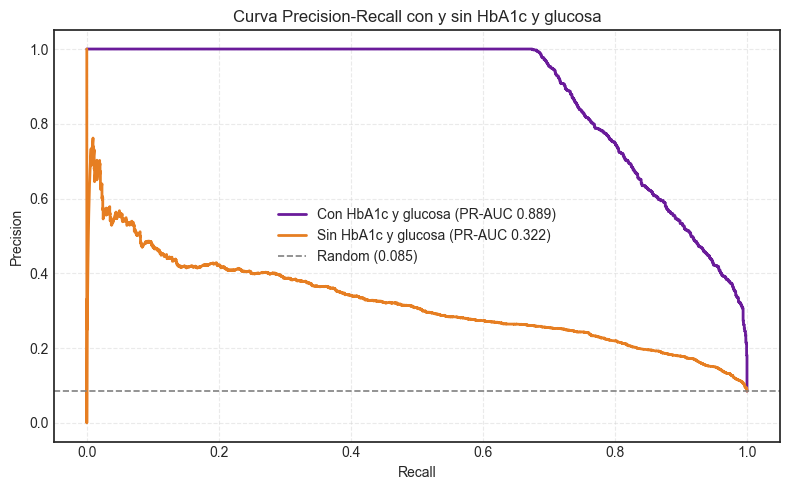

In [16]:
plt.style.use("seaborn-v0_8-white")
prevalencia = y_test.mean()

plt.figure(figsize=(8, 5))
for nombre, proba, color in [
    ("Con HbA1c y glucosa", proba_te,     "#6A1B9A"),
    ("Sin HbA1c y glucosa", proba_te_sin, "#E67E22"),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, color=color, lw=2, label=f"{nombre} (PR-AUC {ap:.3f})")
plt.axhline(prevalencia, ls="--", color="grey", lw=1.2, label=f"Random ({prevalencia:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall con y sin HbA1c y glucosa")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

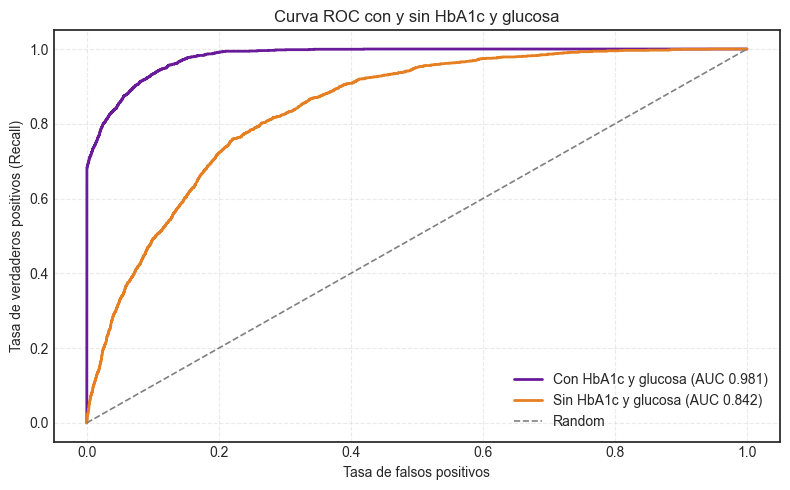

In [17]:
from sklearn.metrics import roc_curve

plt.style.use("seaborn-v0_8-white")

plt.figure(figsize=(8, 5))
for nombre, proba, color in [
    ("Con HbA1c y glucosa", proba_te,     "#6A1B9A"),
    ("Sin HbA1c y glucosa", proba_te_sin, "#E67E22"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{nombre} (AUC {auc:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="grey", lw=1.2, label="Random")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (Recall)")
plt.title("Curva ROC con y sin HbA1c y glucosa")
plt.legend()
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

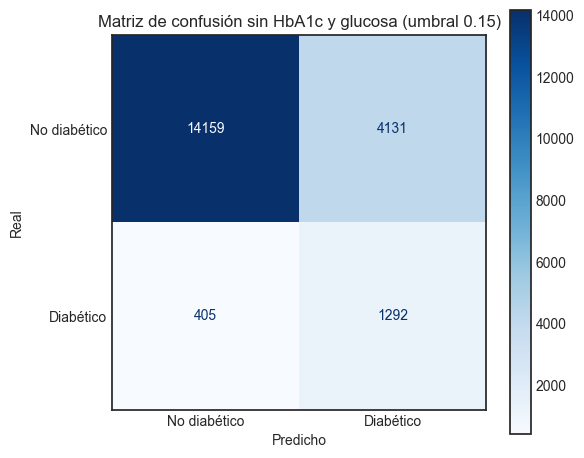

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

pred_te_sin = (proba_te_sin >= opt_t_sin).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_te_sin,
    display_labels=["No diabético", "Diabético"],
    cmap="Blues", colorbar=True, values_format="d", ax=ax,
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión sin HbA1c y glucosa (umbral {opt_t_sin:.2f})")
plt.tight_layout()
plt.show()